# 3. SHO Fitting in Pytorch


In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")
sys.path.append('../../src')
sys.path.append('/home/julian/BEPiezo-Learn/src')
sys.path.append('/home/julian/AutoPhysLearn/src')

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import os
from m3util.viz.printing import printer
from m3util.viz.style import set_style
from m3util.ml.rand import set_seeds
from m3util.util.IO import download_and_unzip
from belearn.dataset.dataset_new import BE_Dataset
from belearn.viz.viz_new import Viz
from belearn.util.wrappers import temporary_state, context_manager_decorator
from belearn.functions.sho import SHO_nn
from belearn.dataset.analytics import print_mse
from belearn.dataset.model import BE_model_utils
from autophyslearn.postprocessing.complex_new import ComplexPostProcessor
from autophyslearn.spectroscopic.nn_new import Multiscale1DFitter, Model


printing = printer(basepath = './Figures/')


set_style("printing")
set_seeds(seed=42)

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
printing set for seaborn
Pytorch seed was set to 42
Numpy seed was set to 42


2025-04-07 12:41:34.544300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744044094.559666  152650 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744044094.564453  152650 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-07 12:41:34.580888: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow seed was set to 42


## Loads Data


In [4]:
# Specify the filename and the path to save the file
filename = 'data_raw.h5'
save_path = "./Data"

data_path = save_path + "/" + filename

In [5]:
# instantiate the dataset object
#dataset = BE_Dataset(data_path, SHO_fit_func_LSQF=SHO_nn)

dataset = BE_Dataset(data_path)


# print the contents of the file
dataset.print_be_tree()

/
├ Measurement_000
  ---------------
  ├ Channel_000
    -----------
    ├ Bin_FFT
    ├ Bin_Frequencies
    ├ Bin_Indices
    ├ Bin_Step
    ├ Bin_Wfm_Type
    ├ Excitation_Waveform
    ├ Noise_Floor
    ├ Noisy_Data_1
    ├ Noisy_Data_2
    ├ Noisy_Data_3
    ├ Noisy_Data_4
    ├ Noisy_Data_5
    ├ Noisy_Data_6
    ├ Noisy_Data_7
    ├ Noisy_Data_8
    ├ Position_Indices
    ├ Position_Values
    ├ Raw_Data
    ├ Raw_Data_Reshaped
    ├ Spatially_Averaged_Plot_Group_000
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spatially_Averaged_Plot_Group_001
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spectroscopic_Indices
    ├ Spectroscopic_Values
    ├ UDVS
    ├ UDVS_Indices
  ├ Raw_D

## Testing the Torch Function

The function for a simple-harmonic oscillator needs to be recast in PyTorch. Here we prove that the PyTorch function is implemented identically to the Numpy model.

Note: This uses the results from the least squares fitting LSQF results.


In [6]:
# insatiate the visualization object
image_scalebar = [2000, 500, "nm", "br"]

BE_viz = Viz(dataset, printing, verbose=True, 
             SHO_ranges = [(0,1.5e-4), (1.31e6, 1.33e6), (-300, 0), (-np.pi, np.pi)],
             image_scalebar=image_scalebar)

In [7]:
#BE_viz.SHO_Scaler()
BE_viz.SHO_preprocessing()

{'resampled': False, 'label': 'True Raw', 'noise': 0, 'measurement_state': 'all'}
***
pixel:  1095
voltage_step:  188
***
True 


            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None)
            Resample = False
            Raw Format = complex
            Fitter = LSQF
            Scaled = False
            Output Shape = pixels
            Measurement State = all
            Resample Resampled = False
            Resample Bins = 165
            LSQF Phase Shift = None
            NN Phase Shift = None
            Noise Level = 0
            Loop Interpolated = False
            
predicted 


            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None)
            Resample = False
            Raw Format = complex
            Fitter = LSQF
            Scaled = False
            Output Shape = pixels
            Measurement State = all
            Resam

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)


./Figures/Figure_3_1_PyTorch_fit_tester_test3.svg


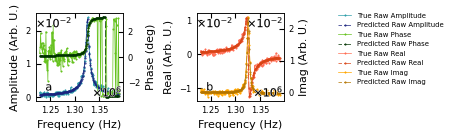

In [8]:
true = {"resampled": False,
        "label": "True Raw",
        "noise": 0, 
        "measurement_state": "all"}

predicted = {"fitter": "LSQF", 
             "resampled": False, "label": "Predicted Raw", 
             "scaled": False, "noise" : 0}
# 130, 149
# 1294, 106

BE_viz.fit_tester(true, predicted, pixel = 1095, voltage_step = 188, filename="Figure_3_1_PyTorch_fit_tester_test3")

**Figure 3.1** Shows the result of the PyTorch function. The result based on the LSQF results shows that the PyTorch function is implemented correctly.


## Pytorch Model

### Model Architecture


### Scaling the Data

When training the neural network it is useful to scale the data. We apply a global scaler such that the spectrum have a mean of 0 and a standard deviation of 1.

#### Visualizing the Scaled Data



            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None)
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = pixels
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = None
            NN Phase Shift = None
            Noise Level = 0
            Loop Interpolated = False
            
./Figures/Figure_3_2_Scaled Raw Data_test.png
./Figures/Figure_3_2_Scaled Raw Data_test.svg


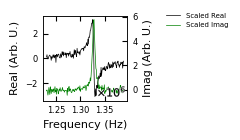

In [9]:
state = {"fitter": "LSQF", "resampled": True, "scaled": True, "label": "Scaled"}

BE_viz.nn_checker(state, filename="Figure_3_2_Scaled Raw Data_test")

**Figure 3.2** shows the scaled data. The data is scaled to have a mean of 0 and a standard deviation of 1. This is done using a global scaler of the entire spectrum.


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)



            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None)
            Resample = False
            Raw Format = complex
            Fitter = LSQF
            Scaled = False
            Output Shape = pixels
            Measurement State = all
            Resample Resampled = False
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = None
            Noise Level = 0
            Loop Interpolated = False
            
./Figures/Figure_3_3_Phase_Shifted_Scaled_Histograms_test.png
./Figures/Figure_3_3_Phase_Shifted_Scaled_Histograms_test.svg


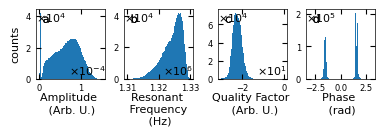

In [10]:
BE_viz.LSQF_phase_shift = np.pi / 2

BE_viz.SHO_hist(
    BE_viz.SHO_fit_results(), filename="Figure_3_3_Phase_Shifted_Scaled_Histograms_test"
)

**Figure 3.3** shows the histograms of the scaled a) amplitude, b) resonance frequency, c) quality factor, and d) phase. These are approximated from the LSQF. These are the scaled values that are predicted by the neural network. Note there is a transformation applied to the phase.


### Training the Model

We will train the model from scratch. Generally the model trains very well in a few epochs. This will take less than 5 minutes to train on a GPU.


In [ ]:
seed=42

os.environ["PYTHONHASHSEED"] = str(seed)


set_seeds(seed=seed)

device = torch.device("cuda:0")

postprocessor = ComplexPostProcessor(BE_viz,device=device)

model_ = Multiscale1DFitter(SHO_nn, # function 
                            BE_viz.frequency_bin, # x data
                            2, # input channels
                            4, # output channels
                            BE_viz.SHO_scaler, 
                            postprocessor,
                            device=device)


# # instantiate the model
# model = Model(model_, dataset, training=True, model_basename="SHO_Fitter_original_data_test", 
#               datafed_path = "2024_SHO_Fitting/Original_NN_SHO_Fitter", 
#               script_path = f"{os.getcwd()}/3_Pytorch_SHO_Fitter copy.ipynb",
#               dataset_id = 'd/525631097',
#               device=device)


# instantiate the model
model = Model(model_, BE_viz, training=True, model_basename="SHO_Fitter_original_data_test", 
              datafed_path = "2024_SHO_Fitting/Original_NN_SHO_Fitter", 
              script_path = f"{os.getcwd()}/3_Pytorch_SHO_Fitter copy.ipynb",
              dataset_id = 'd/525631097',
              device=device)

Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42


In [12]:
model_utils = BE_model_utils(model, BE_viz)

In [13]:
# constructs a test train split
X_train, X_test, y_train, y_test = model_utils.test_train_split_(scaled=True, shuffle=True)

In [14]:
train = True

if train:
    # fits the model
    model.fit(
        X_train,
        500,
        optimizer="Adam",
        epochs = 5,
        device=device
    )
else:
    model.load(
        "/home/ferroelectric/m3_learning/m3_learning/papers/2023_Rapid_Fitting/Trained Models/SHO Fitter/SHO_Fitter_original_data_model_epoch_5_train_loss_0.0449272525189978.pth",
        device=device
    )

Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647382455/work/torch/csrc/autograd/engine.cpp:1201.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam
epoch : 1/5, recon loss = 0.06531872
--- 18.08665418624878 seconds ---
Epoch 1, Learning Rate: 0.001
Adam
epoch : 2/5, recon loss = 0.03467956
--- 17.939712524414062 seconds ---
Epoch 2, Learning Rate: 0.001
Adam
epoch : 3/5, recon loss = 0.03432068
--- 17.830098628997803 seconds ---
Epoch 3, Learning Rate: 0.001
Adam
epoch : 4/5, recon loss = 0.03412755
--- 17.879223823547363 seconds ---
Epoch 4, Learning Rate: 0.001
Adam
epoch : 5/5, recon loss = 0.03404734
--- 17.930309534072876 seconds ---
Epoch 5, Learning Rate: 0.001


In [16]:
from datafed.CommandLib import API

df_api = API()

df_api.collectionGetParents('d/525655818')

(path {
   item {
     id: "c/525610596"
     title: "Original_NN_SHO_Fitter"
   }
   item {
     id: "c/p_2024_sho_fitting_root"
     title: "Root Collection"
     alias: "root"
   }
 },
 'CollPathReply')

In [19]:
print(df_api.getAuthUser())
print(df_api.endpointDefaultGet())


u/jg3837
f451f512-d437-11ef-9bd6-191f082cca5d


In [23]:
df_api.collectionGetParents('d/525631097')

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/datafed/Connection.py:200: UserWarning: reflection.ParseMessage() is deprecated. Please use MessageFactory.GetMessageClass() and message.ParseFromString() instead. reflection.ParseMessage() will be removed in Jan 2025.
  reply = google.protobuf.reflection.ParseMessage(desc, data)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/google/protobuf/reflection.py:59: UserWarning: reflection.MakeClass() is deprecated. Please use MessageFactory.GetMessageClass() instead. reflection.MakeClass() will be removed in Jan 2025.
  result_class = MakeClass(descriptor)


(path {
   item {
     id: "c/525610729"
     title: "Training_Benchmarks_NN_SHO_11_04_2024"
   }
   item {
     id: "c/p_2024_sho_fitting_root"
     title: "Root Collection"
     alias: "root"
   }
 },
 'CollPathReply')

### Evaluate the Neural Network Results

It is always recommended to validate that the autoencoder is working correctly. We can do this by comparing the different stages of the autoencoder including the raw data, the generated curves.


In [14]:
type(X_train)

torch.Tensor

In [15]:
np.iscomplex(X_train).all()

np.False_

In [19]:
X_train[0][0]

tensor([0.0006, 0.0008])

In [27]:
import torch

In [28]:
isinstance(X_train, (torch.Tensor, np.ndarray))

True

In [43]:
X_train.device

device(type='cpu')

In [17]:
BE_viz.resampled

True

In [15]:
model.device

device(type='cuda', index=0)

In [16]:
X_train.device

device(type='cpu')

In [ ]:
# hidden_x1 slightly different on Shenron 

index1 [169376 240602 886945]
./Figures/Figure_10_NN_validation_Train_test_sorted.png
./Figures/Figure_10_NN_validation_Train_test_sorted.svg


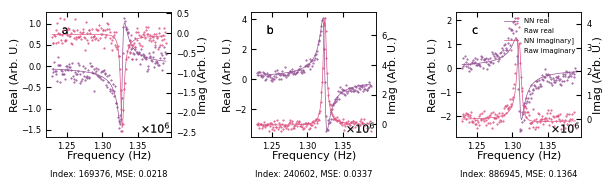

In [14]:
d1, d2, index1, mse1 = BE_viz.bmw_nn(
    X_train,
    prediction=model,
    out_state={"scaled": True, "raw_format": "complex"},
    returns=True,
    filename="Figure_10_NN_validation_Train_test_sorted",
)

In [ ]:
# index[527157-5:527157+5]
# array([ 544511,   42617,  896604,  480474,  904339,  701206,  914630,
#         345836,  972550, 1093856])

**Figure 3.4** Raw data and reconstruction of the autoendcoder for the training data. Shows the a) best, b) median, and c) worst reconstruction of the training data.


index1 [150599 238257 173205]
./Figures/Figure_11_NN_validation_test_2_fixed_seed.png
./Figures/Figure_11_NN_validation_test_2_fixed_seed.svg


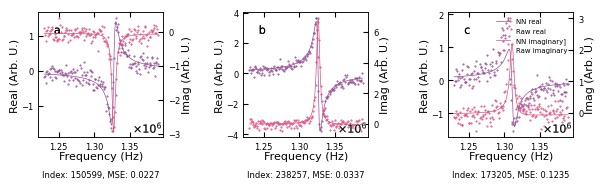

In [15]:
d1, d2, index1, mse1 = BE_viz.bmw_nn(
    X_test,
    prediction=model,
    out_state={"scaled": True, "measurement State": "complex"},
    returns=True,
    filename="Figure_11_NN_validation_test_2_fixed_seed",
)

In [56]:
X_test.shape[0]/2

138240.0

In [17]:
X_test[162152,:,0]

tensor([-0.0863,  0.3009,  0.1713,  0.0620,  0.3603,  0.1639,  0.2898, -0.1597,
        -0.1593,  0.0568,  0.1260,  0.3394,  0.0809,  0.1381,  0.2038,  0.1848,
         0.1917,  0.1627, -0.1711,  0.1824,  0.2224,  0.4486,  0.2001,  0.1751,
         0.2659,  0.4135,  0.0761,  0.2818, -0.0276,  0.2930,  0.2020,  0.2068,
         0.2193,  0.4310,  0.3610,  0.2733,  0.2800,  0.3298,  0.3695,  0.2898,
         0.3775,  0.2368,  0.1470,  0.1183,  0.5338,  0.3289,  0.3677,  0.3479,
         0.6794,  0.0537,  0.4940,  0.4348, -0.1292,  0.6825,  0.2782,  0.4023,
         0.5991,  0.3285,  0.4275,  0.7335,  0.5663,  0.3048,  0.2455,  0.7957,
         0.2802,  0.4615,  0.8337,  0.4622,  0.7264,  0.6761,  0.4375,  0.7364,
         0.7452,  0.8773,  0.8053,  0.7318,  0.5432,  1.0411,  1.0651,  0.9704,
         1.2991,  1.9177,  1.4989,  1.5715,  1.5536,  1.8397,  1.7033,  2.4272,
         2.2427,  2.4550,  2.1516,  2.0788,  1.5283, -0.3542, -1.4396, -2.1547,
        -2.8073, -2.7521, -2.3107, -2.27

In [24]:
import matplotlib.pyplot as plt

In [26]:
d1.shape

(3, 2, 165)

In [28]:
d1[0][0].shape

(165,)

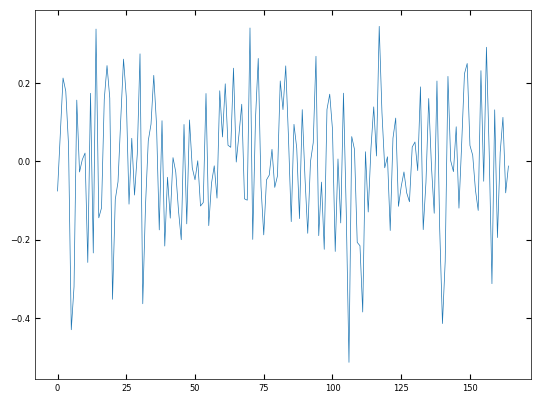

In [35]:
plt.plot(d1[1][0])

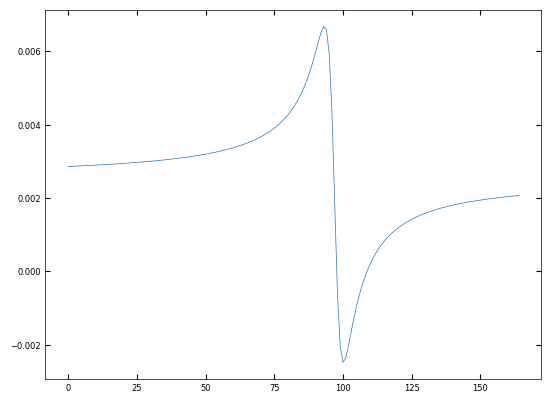

In [34]:
plt.plot(d2[1][0])

In [40]:
X_test[10,:,0].shape

torch.Size([165])

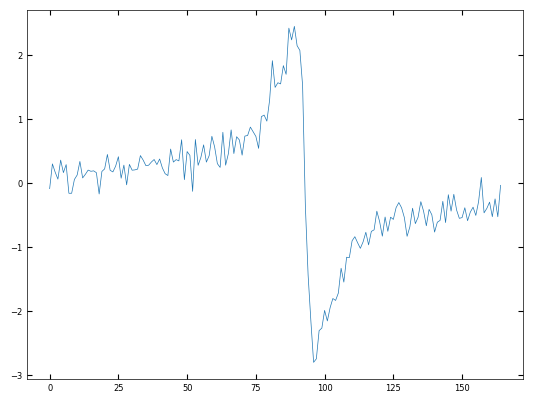

In [51]:
plt.plot(X_test[162152,:,0])

**Figure 3.5** Raw data and reconstruction of the autoendcoder for the test data. Shows the a) best, b) median, and c) worst reconstruction of the test data.


./Figures/Figure_12_NN_validation_full_data_test.png
./Figures/Figure_12_NN_validation_full_data_test.svg


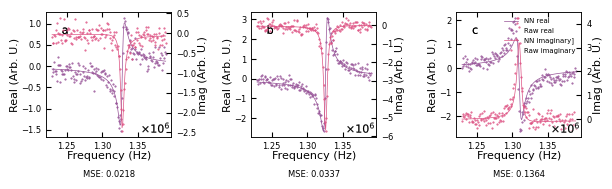

In [15]:
state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": False,
    "scaled": True,
    "output_shape": "index",
}

X_data, Y_data = model_utils.NN_data()

X_data = X_data.to(device)
Y_data = Y_data.to(device)

d1, d2, index1, mse1 = BE_viz.bmw_nn(
    state,
    prediction=model,
    out_state={"scaled": True, "measurement State": "complex"},
    returns=True,
    filename="Figure_12_NN_validation_full_data_test",
)

**Figure 3.6** Raw data and reconstruction of the autoendcoder for the entire data. Shows the a) best, b) median, and c) worst reconstruction of the entire data.


In [16]:
print(X_data.device, model.device)
print(X_data.shape)

cuda:0 cuda:0
torch.Size([1382400, 165, 2])


### Calculate the MSE error

We can calculate the MSE error for the training, test, and entire data set.


In [ ]:
LSQF_ = {'resampled': True,
                'raw_format': 'complex',
                'fitter': 'LSQF',
                'scaled': True,
                'output_shape': 'index',
                'measurement_state': 'all',
                'resampled_bins': 165,
                'LSQF_phase_shift': 1.5707963267948966,
                'NN_phase_shift': None,
                'noise': 0}

data = (LSQF_, X_data, X_test, X_train)
labels = ["LSQF", "Full Data", "Test Data", "Train Data"]

# JGoddy added is_SHO=True. this might be wrong but otherwise the shapes don't match
print_mse(model_, model, model_utils, data, labels,is_SHO=True) 

LSQF Mean Squared Error: 0.0344539
Full Data Mean Squared Error: 0.0338697
Test Data Mean Squared Error: 0.0338612
Train Data Mean Squared Error: 0.0338718


From here on out we will assume that the autoencoder is working correctly, and is not overfit. This is a good assumption because the results are more or less the same for the training, test, and entire data set.

We note that the MSE error is not a true indicator that the model is doing a better job extracting the physics parameters of the data. 

### GPU Inference Speedtest

Here we show the speedtest for the GPU. This is done using the torch.cuda.synchronize() function. This is used to ensure that the GPU is done processing before the timer is stopped.


In [20]:
#X_data, Y_data = dataset.NN_data()

model.inference_timer(X_data, batch_size=1000)

Mean execution time computed for 1383 batches of size 1000
Average execution time per batch (ms): 1.377144 ± 0.228467
Average execution time per iteration (ms): 0.001377 ± 0.000228
Total execution time (s): 1.90 


### Histogram of Fit Results

It is useful to view the histogram of the fitting results to apply any necessary phase shifts, and to see if the results are reasonable.


In [ ]:
# we will add the appropriate phase shift to the dataset based on the fix seed,
# If your seed is different the results might vary
dataset.NN_phase_shift = np.pi/2 

# you can view the test and training dataset by replacing X_data with X_test or X_train
pred_data, scaled_param, parm = model.predict(X_data)

BE_viz.SHO_hist(parm, filename="Figure_13_NN_Unscaled_Parameters_Histograms_test")

**Figure 3.7** Histogram of the fit results for the a) amplitude, b) resonance frequency, c) quality factor, and d) phase.


In [ ]:
out = dataset.SHO_scaler.transform(parm)

BE_viz.SHO_hist(out, filename="Figure_13_NN_scaled_Parameters_Histograms_test", scaled=True)

**Figure 3.8** Histogram of the fit results for the a) amplitude, b) resonance frequency, c) quality factor, and d) phase. The histograms show the scaled parameters.


In [ ]:
# you can view the test and training dataset by replacing X_data with X_test or X_train
pred_data, scaled_param, parm = model.predict(X_data)

BE_viz.SHO_switching_maps(parm, filename="Figure_15_NN_Switching_Maps_test")

**Figure 3.9** Snapshots of the amplitude, resonance frequency, quality factor, and phase of the piezoresponse during ferroelectric switching.

## SHO Fitting Movies

In [ ]:
# Insatiate the visualization object
image_scalebar = [2000, 500, "nm", "br"]

BE_viz = Viz(dataset, printing, verbose=True, 
             SHO_ranges = [(0,1.5e-4), (1.31e6, 1.33e6), (-300, 0), (-np.pi, np.pi)],
             image_scalebar=image_scalebar)

In [ ]:
BE_viz.SHO_fit_movie_images(noise = 0, 
                            models = [model],
                            scalebar_= True, 
                            basepath = "Movies/SHO_NN_",  
                            filename="SHO_NN",
                            phase_shift = [np.pi/2],)

## Comparison SHO and Neural Network Fits

3 graphs, best, median, worst

histograms of parameters.


In [ ]:
# sets the phase shift of the dataset
dataset.NN_phase_shift = np.pi/2
dataset.LSQF_phase_shift = np.pi/2
dataset.measurement_state = "all"

# sets the true state which to compare the results.
true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}

# sets the state of the output data
out_state = {"scaled": True, "raw_format": "magnitude spectrum"}

# sets the number of examples to get
n = 1

LSQF = BE_viz.get_best_median_worst(
    true_state,
    prediction={"fitter": "LSQF"},
    out_state=out_state,
    SHO_results=True,
    n=n,
)

NN = BE_viz.get_best_median_worst(
    true_state, prediction=model, out_state=out_state, SHO_results=True, n=n
)

data = (LSQF, NN)
names = ["LSQF", "NN"]

BE_viz.SHO_Fit_comparison(
    data,
    names,
    model_comparison=[model, {"fitter": "LSQF"}],
    out_state=out_state,
    filename="Figure_14_LSQF_NN_bmw_comparison_test",
    verbose=False,
)

**Figure 3.10** Comparison of the a,b) best , c,d) median, and e,f) worst simple harmonic oscillator fits. a,c,e) are based on the fit results from the simple harmonic oscillator model, wherein b,d,f) are based on the neural network model. Generally speaking, all fits are good for both models on the as collected data.

### Statistics of the Results for Training, Validation, and Entire Dataset


In [ ]:
true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}


BE_viz.violin_plot_comparison_SHO(true_state, model, X_data, filename="Figure_16_Violin_test") 


**Figure 3.11** Violin plot showing the difference in the distribution for the fit results for the LSQF algorithm show in blue, and the NN shown in orange. 

### SHO Comparison Movie

In [ ]:
BE_viz.SHO_fit_movie_images(noise = 0, 
                            models=[None, model], 
                            scalebar_= True, 
                            basepath = "Movies/SHO_NN_LSQF_Compare_",  
                            filename="SHO_NN_LSQF_Compare", 
                            labels = ['LSQF', 'NN'],
                            phase_shift = [np.pi/2, np.pi/2])

### Outliers Visualization

Resonance outliers

In [ ]:

dataset.measurement_state = "all"
dataset.NN_phase_shift = np.pi/2
dataset.LSQF_phase_shift = np.pi/2

true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}

# gets the parameters from the SHO LSQF fit
true = dataset.SHO_fit_results(state = true_state).reshape(-1, 4)

# finds the index less than a certain value
ind = np.argwhere(true[:,1]< -3).flatten()


true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all"
}

out_state = {"raw_format": "magnitude spectrum", "measurement_state": "all"}

n = 1

LSQF = BE_viz.get_best_median_worst(
    true_state,
    prediction={"fitter": "LSQF"},
    out_state=out_state,
    SHO_results=True,
    n=n,
    index = ind,
    verbose = False
)

NN = BE_viz.get_best_median_worst(
    true_state, prediction=model,
    out_state=out_state, SHO_results=True, n=n, index = ind, verbose = False,
)

data = (LSQF, NN)
names = ["LSQF", "NN"]

BE_viz.SHO_Fit_comparison(
    data,
    names,
    model_comparison=[model, {"fitter": "LSQF"}],
    out_state=out_state,
    filename="Figure_14_LSQF_NN_bmw_comparison",
    verbose = False
)

**Figure 3.12** One thing that was noticed was the LSQF results showed outliers for the Resonance. We find all values from the outlier distribtion from the LSQF, and plot the comparison of the a,b) best , c,d) median, and e,f) worst simple harmonic oscillator fits. a,c,e) are based on the fit results from the simple harmonic oscillator model, wherein b,d,f) are based on the neural network model. The neural network performs better in this distribution. It is worth noting that the best response is obtained when the amplitude, and thus the error, is small. 